# Logistic Regression Cost Function

# Goal

- Implement the logistic cost function.
- 로지스틱 cost function을 직접 구현한다.

- Understand lower cost means a better model.
- cost가 낮을수록 더 좋은 모델임을 이해한다.

- Compare two decision boundaries using cost.
- 두 decision boundary를 cost로 비교한다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 데이터 준비
X_train = np.array([
    [0.5, 1.5],
    [1.0, 1.0],
    [1.5, 0.5],
    [3.0, 0.5],
    [2.0, 2.0],
    [1.0, 2.5]
])

y_train = np.array([0, 0, 0, 1, 1, 1])

print(X_train.shape)
print(y_train.shape)

(6, 2)
(6,)


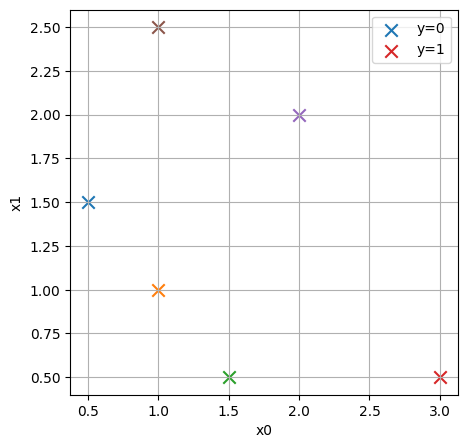

In [3]:
# 데이터 시각화
plt.figure(figsize=(5, 5))

for i in range(len(y_train)):
    if y_train[i] == 1:
        plt.scatter(X_train[i, 0], X_train[i, 1], marker='x', s=80, label='y=1' if i==3 else "")
    else:
        plt.scatter(X_train[i, 0], X_train[i, 1], marker='x', s=80, label='y=0' if i==0 else "")
    
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# sigmoid 함수
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [6]:
# 예측 함수
def predict(x, w, b):
    z = np.dot(x, w) + b
    return sigmoid(z)

In [ ]:
def logistic_loss(fx, y):
    return -(y * np.log(fx) + (1-y) * np.log(1-fx))

In [8]:
# Cost Function 구현
def compute_cost_logistic(X, y, w, b):
    m = X.shape[0]
    cost = 0

    for i in range(m):
        fx = predict(X[i], w, b)
        cost += logistic_loss(fx, y[i])

    return cost / m

In [11]:
# 첫 번째 파라미터 테스트
w = np.array([1, 1])
b = -3

cost = compute_cost_logistic(X_train, y_train, w, b)
print(cost)

0.36686678640551745


In [12]:
# 두 번째 파라미터 테스트
w2 = np.array([1, 1])
b2 = -4

cost2 = compute_cost_logistic(X_train, y_train, w2, b2)
print(cost2)

0.5036808636748461


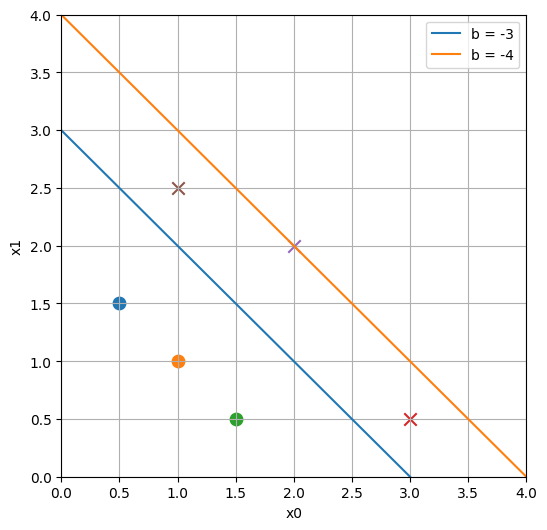

In [13]:
# Decision Boundary 시각화
x0 = np.linspace(0, 4, 100)

x1_blue = 3 - x0
x1_magenta = 4 - x0

plt.figure(figsize=(6, 6))

plt.plot(x0, x1_blue, label="b = -3")
plt.plot(x0, x1_magenta, label="b = -4")

for i in range(len(y_train)):
    if y_train[i] == 1:
        plt.scatter(X_train[i, 0], X_train[i, 1], marker='x', s=80)
    else:
        plt.scatter(X_train[i, 0], X_train[i, 1], marker='o', s=80)

plt.xlim(0,4)
plt.ylim(0,4)
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.grid(True)
plt.show()

## why is b = -3 better?
## 왜 b = -3이 더 좋은가?

The boundary separates the classes better.
경계선이 데이터를 더 잘 분리한다.

So the predictions are better.
예측이 더 정확하다.

Therefore the cost is lower.
그래서 cost가 더 낮다.

## Final Summary
## 최종 정리

Cost is the average logistic loss over all examples.
Cost는 모든 샘플의 평균 logistic loss이다.

Lowe cost means a better fitting model.
cost가 낮을수록 더 좋은 모델이다.

Gradient descent will try to minimize this cost.
Gradient descent는 이 cost를 줄이는 방향으로 학습한다.